# Определение поворота текста на 180°

Это ноутбук для тестового задания на avito-bootcamp.

**ВАЖНО:** Я специально сделал 2 ячейки в конце автономными, чтобы они собрали submission, чтобы можно было запустить без датасета, используя только веса модели.
Если прогонять весь ноутбук, то предпоследнюю ячейку (которая отвечает за автономность) можно не запускать, submission все равно будет таким же.

Прежде чем переходить к самому ноутбуку, я хочу ниже описать проделанную работу и ход решения. Я также хотел бы поделиться своими мыслями и гипотезами, что можно было бы сделать по-другому или попробовать, такой блок я вынес в конец ноутбука, чтобы вы, проверяющий, сначала ознакомились с самой работой.

## Сбор данных.

Для начала я просмотрел изображения тестовой выборки, чтобы понять, что она в себя включает. В основном это очень плотные кропы горизонтального текста, обычно русского и английского и редко встречаются текст под углом, плохое качество и так далее. Это важно учесть, к этому вернусь ещё потом.

Я взял 2 открытых датасета с кропами английского языка: [ch4](https://rrc.cvc.uab.es/?ch=4&com=downloads) (тут нужна регистрация) и [iiit5k](https://cvit.iiit.ac.in/research/projects/cvit-projects/the-iiit-5k-word-dataset). Также я нашел датасет с преимущественно русскими кропами - [rustitw](https://www.kaggle.com/datasets/hardtype/rustitw-russian-language-visual-text-recognition). Из него я взял только real изображения. Все это объединил в один датасет.

Самым похожим на тестовую выборку оказался iiit5k - там плотные четкие кропы, но, к сожалению, язык только английский.

Ch4 похож на iiit5k, но больше изображений плохого качества или в блюре.

В rustitw вообще часто кроп под углом, включает в себя несколько строк текста (что очень редко встречалось в тестовой выборке), есть тоже изображения плохого качества и, что немало важно, встречается сложный фон: например кирпичная стена, тень, падающая на текст и т.д. Тем не менее, датасет полезен, во-первых, потому что много примеров, во-вторых, потому что есть текст на русском языке.

## Предобработка данных.

Я посмотрел немного статистики датасета rustitW (остальные уже предобработаны хорошо), и на гистограммах было видно, что есть пару выбросов: встречался вертикальный текст или очень большие кропы.

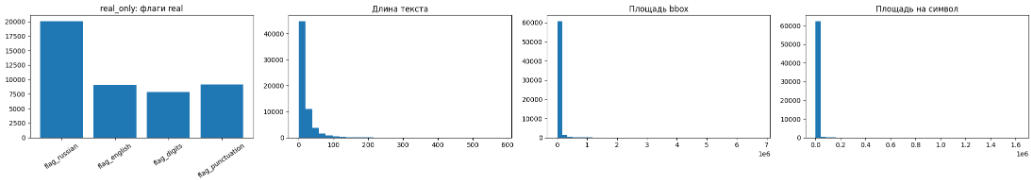

P.s. график я делал на каггле, когда экспортировал датасет, поэтому в этом ноутбуке его нет.

Также я решил немного предобработать датасет и с помощью easyOCR обрезал кропы rustitw поплотнее. Я не обрезал изображения, которые: по тексту (его аннотации предоставлены в датасете) не совпадали с распознанием easyOCR или где изменение bbox'а было меньше 2%. Итого я обрезал 40% изображений rustitw и сократил на них площадь тоже приблизительно на 40%:

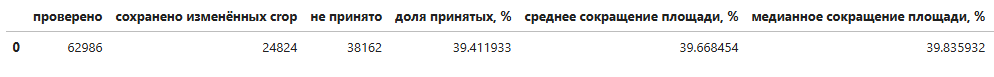

Дальше у меня встал вопрос, как лучше сжать изображение для входа в модель. Во-первых, я сохранял соотношение сторон, чтобы текст не растягивался и не сжимался. Во-вторых, я попробовал два варианта:

1) паддить до квадрата 224x224 белыми пикселями
2) паддить до прямоуголньика медианным пикселем по краям изображения

далее экспериментально получил, что второй вариант лучше. Поэтому итоговое решение использовало этот вариант. Графики:

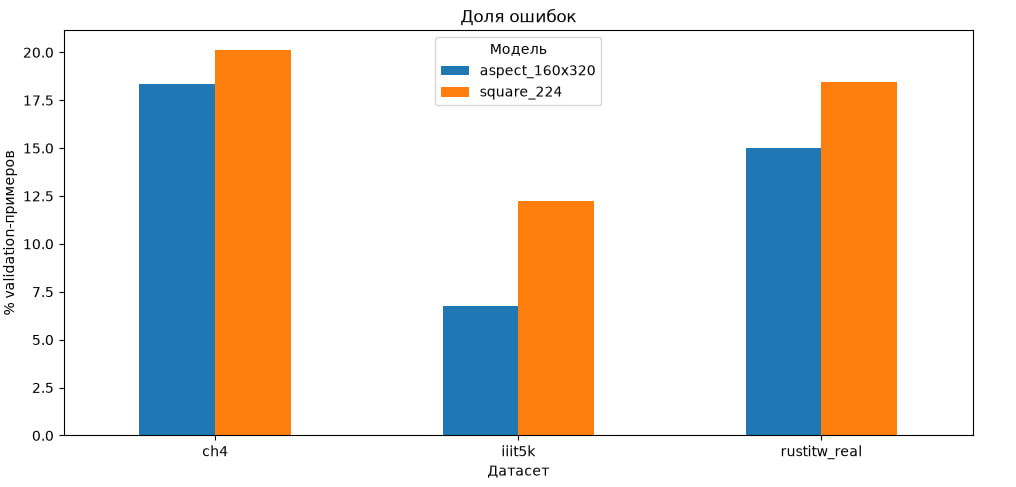
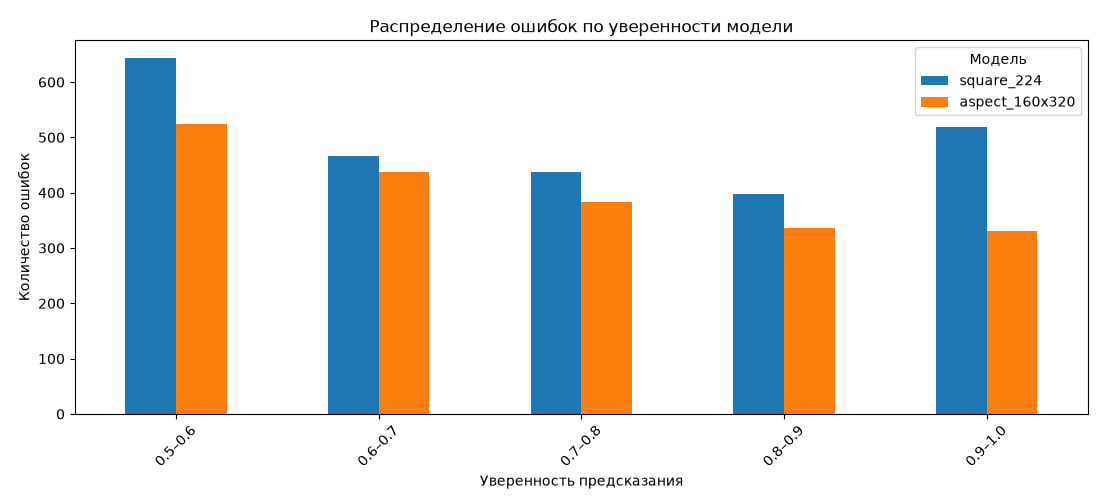

Обучение и сравнение 224x224 можно воспроизвести, если ниже в первой ячейке заменить RUN_EXPERIMENTS 
## Обучение

Модель:

Я взял модель mobilenetv3 за счёт её скорости и компактности. Не отрицаю, что модель покрупнее, например, ResNet-18, могла бы выдать качество лучше, но ввиду ограниченного времени и условия на производительность не стал пробовать другие модели и остановился на mobilenetv3. Я загружал её дефолтные предобученные веса для того, чтобы просто зафайнтюнить под нашу задачу.

Loss и оптимизатор:

Я минимизировал бинарную кроссэнтропию. Минимизировать именно brier score не лучшая идея из-за слабого исправления слишком уверенных предсказаний, на них градиент маленький. Можно было попробовать связку alpha1 * BCE + alpha2 * Brier, но чистый brier я бы даже не стал пробовать.

Оптимизатор adamW с cosinescheduler.

## Анализ полученной модели:

Сразу скажу, что критической я считал ошибку, которая имеет уверенность >= 0.9.

Я вывел топ 10 ошибок модели и посмотрел на ответы модели если исказить изображения путем применения аугментаций. На первый взгляд решение немного менялось из-за blur, поэтому я решил ещё раз прогнать всю валидационную выборку в 4-х экземплярах: один исходный и 3 с разными аугментациями. Прироста в предсказании это не дало, но зато, например, затемнение уменьшило количество критических ошибок. Это интересное наблюдение, которое может говорить о том, что есть над чем поработать в данных ещё.

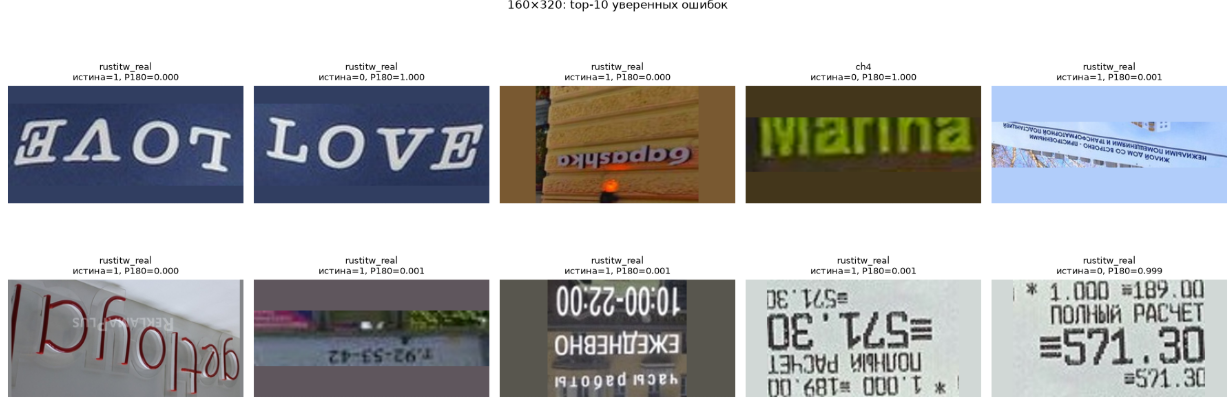

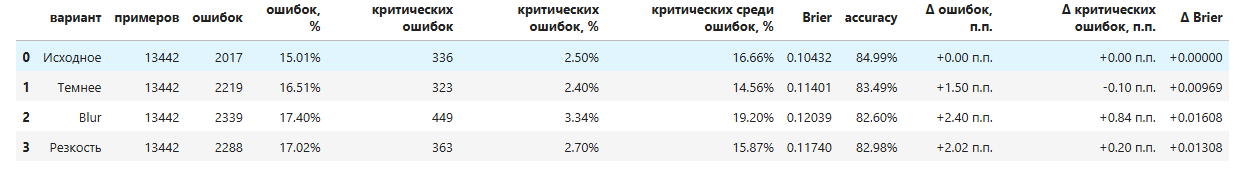

Вдобавок вывел топ 10 лучших предсказаний, несколько из них симметричны, что является хорошим знаком.

Далее я попробовал изменить температуру: `sigmoid(logits / T)`, она в теории должна увеличивать brier score, но заметного улучшения я не получил.

Я прогнал модель через валидационную выборку, в которой заменил easyOCR кропы на исходные (кропы менее плотные). На такой выборке я получил на 200 ошибок больше, что говорит о том, что easyOCR кропы (более плотные кропы, а они же более похожие на тестовую выборку) лучше оценивают модель.

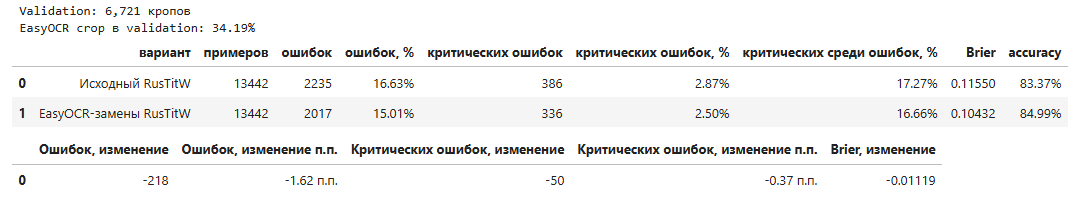

### Импорт и параметры
В ячейке ниже просто импорты библиотек и задание некоторых констант.

In [24]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageEnhance, ImageFilter
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small

# Пути и воспроизводимость
ROOT = Path.cwd()
DATASET_DIR = ROOT / 'data_merged_easy'
SEED = 2026
VAL_FRACTION = 0.10

# Обучение
BATCH_SIZE = 256
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
FORCE_TRAIN = False
# Для воспроизведения сравнения: ('square_224', 'aspect_160x320')
RUN_EXPERIMENTS = ('aspect_160x320',)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
print('Устройство:', DEVICE)

Устройство: cuda


## 1. Единый group-safe split

`from_image_id` связывает все crop, полученные из одной исходной фотографии. Разбиение выполняется по этим идентификаторам, поэтому связанные crop не могут одновременно попасть в train и validation. Для CH4 и IIIT5K один исходный файл соответствует одной группе.

In [25]:
all_examples = pd.read_csv(DATASET_DIR / 'manifest.csv')
all_examples['path'] = all_examples.file_name.map(lambda name: str(DATASET_DIR / 'images' / name))

split_rng = np.random.default_rng(SEED)
parts = []
for dataset_name, frame in all_examples.groupby('dataset', sort=True):
    from_image_ids = np.array(frame['from_image_id'].unique(), copy=True)
    split_rng.shuffle(from_image_ids)
    val_ids = set(from_image_ids[:round(len(from_image_ids) * VAL_FRACTION)])
    split = np.where(frame.from_image_id.isin(val_ids), 'val', 'train')
    parts.append(frame.assign(split=split))

examples = pd.concat(parts, ignore_index=True)
train_examples = examples.loc[examples.split == 'train'].reset_index(drop=True)
val_examples = examples.loc[examples.split == 'val'].reset_index(drop=True)
display(pd.crosstab(examples.dataset, examples.split, margins=True))

split,train,val,All
dataset,,,
ch4,4021,447,4468
iiit5k,1800,200,2000
rustitw_real,56912,6074,62986
All,62733,6721,69454


## 2. Подготовка изображений

Оба варианта сохраняют исходное соотношение сторон и используют одинаковую интерполяцию: LANCZOS при уменьшении и BICUBIC при увеличении. Различаются только размер входа и фон padding: белый для 224×224, медианный цвет границы crop для 160×320.

In [26]:
def normalize_image(image):
    transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ])

    return transform(image)


def median_border_color(image):
    pixels = np.asarray(image)
    border = np.concatenate([pixels[0], pixels[-1], pixels[:, 0], pixels[:, -1]])
    return tuple(int(value) for value in np.median(border, axis=0))


def resize_and_pad(image, size, padding):
    target_h, target_w = size
    image = image.convert('RGB')
    width, height = image.size
    scale = min(target_w / width, target_h / height)
    new_width = max(1, round(width * scale))
    new_height = max(1, round(height * scale))

    interpolation = Image.Resampling.LANCZOS if scale < 1 else Image.Resampling.BICUBIC
    image = image.resize((new_width, new_height), interpolation)
    fill = (255, 255, 255) if padding == 'white' else median_border_color(image)

    canvas = Image.new('RGB', (target_w, target_h), fill)
    offset = ((target_w - new_width) // 2, (target_h - new_height) // 2)
    canvas.paste(image, offset)
    return canvas


def prepare_square(image):
    return resize_and_pad(image, size=(224, 224), padding='white')


def prepare_wide(image):
    return resize_and_pad(image, size=(160, 320), padding='median_border')


EXPERIMENTS = {
    'square_224': {
        'prepare': prepare_square,
        'shape': '224×224',
        'padding': 'white',
    },
    'aspect_160x320': {
        'prepare': prepare_wide,
        'shape': '160×320',
        'padding': 'median_border',
    },
}

## 3. Dataset с поворотом на лету

В эпохе 0 половина кропов получает 180° по фиксированному случайному permutation. В эпохе 1 каждый кроп и его метка инвертируются, в эпохе 2 возвращаются к состоянию эпохи 0 и так далее. Validation виртуально содержит обе ориентации каждого кропа.


In [27]:
class TrainRotationDataset(Dataset):
    def __init__(self, frame, prepare):
        self.frame = frame.reset_index(drop=True)
        self.prepare = prepare
        self.epoch = 0
        self.base_flip = np.zeros(len(self.frame), dtype=np.uint8)
        permutation = np.random.default_rng(SEED).permutation(len(self.frame))
        self.base_flip[permutation[:len(self.frame) // 2]] = 1

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        label = int(self.base_flip[index] ^ (self.epoch % 2))
        with Image.open(self.frame.iloc[index].path) as opened:
            image = opened.convert('RGB')
        if label:
            image = image.transpose(Image.Transpose.ROTATE_180)
        return normalize_image(self.prepare(image)), torch.tensor(float(label)), index


class ValidationRotationDataset(Dataset):
    def __init__(self, frame, prepare):
        self.frame = frame.reset_index(drop=True)
        self.prepare = prepare

    def __len__(self):
        return 2 * len(self.frame)

    def load_pil(self, index):
        source_index, label = index // 2, index % 2
        with Image.open(self.frame.iloc[source_index].path) as opened:
            image = opened.convert('RGB')
        if label:
            image = image.transpose(Image.Transpose.ROTATE_180)
        return self.prepare(image)

    def __getitem__(self, index):
        label = index % 2
        image = self.load_pil(index)
        return normalize_image(image), torch.tensor(float(label)), index

In [28]:
train_datasets = {
    name: TrainRotationDataset(train_examples, config['prepare'])
    for name, config in EXPERIMENTS.items()
}
val_datasets = {
    name: ValidationRotationDataset(val_examples, config['prepare'])
    for name, config in EXPERIMENTS.items()
}

train_loaders = {}
val_loaders = {}
for name in EXPERIMENTS:
    loader_generator = torch.Generator().manual_seed(SEED)
    train_loaders[name] = DataLoader(
        train_datasets[name],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == 'cuda',
    )
    val_loaders[name] = DataLoader(
        val_datasets[name],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == 'cuda',
    )

# 224x224 будет иметь столько же изображений
print('Train:', len(train_datasets['aspect_160x320']))
print('Validation:', len(val_datasets['aspect_160x320']))

Train: 62733
Validation: 13442


In [40]:
# Проверяем схему меток до запуска обучения.
debug_dataset = train_datasets['aspect_160x320']
epoch_0 = debug_dataset.base_flip
epoch_1 = debug_dataset.base_flip ^ 1
print('Train-кропов:', len(debug_dataset))
print('Эпоха 0: метка 180° у', int(epoch_0.sum()), 'кропов')
print('Эпоха 1: метка 180° у', int(epoch_1.sum()), 'кропов')
print('Для каждого crop метки противоположны:', bool(np.all(epoch_0 != epoch_1)))
print('Validation:', len(val_datasets['aspect_160x320']), 'примеров - по 0° и 180° для каждого crop.')

Train-кропов: 62733
Эпоха 0: метка 180° у 31366 кропов
Эпоха 1: метка 180° у 31367 кропов
Для каждого crop метки противоположны: True
Validation: 13442 примеров - по 0° и 180° для каждого crop.


## 4. Обучение моделей

Каждый эксперимент использует собственный checkpoint. `FORCE_TRAIN=True` в первой ячейке эксперимент/ы заново; иначе существующий checkpoint загружается и соответствующее обучение пропускается. В логах отдельно выводятся BCE и Brier для train/validation.

In [30]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_bce = total_brier = total_count = 0

    with torch.enable_grad():
        for images, targets, _ in tqdm(loader, leave=False, desc='Train'):
            # non_blocking позволяет асинхронно передавать batch из RAM в VRAM.
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            # Mixed precision снижает расход VRAM, что полезно для видеокарты с 6 ГБ памяти.
            # GradScaler защищает маленькие float16-градиенты от округления до нуля.
            with torch.autocast(
                device_type=DEVICE.type,
                enabled=DEVICE.type == 'cuda',
            ):
                logits = model(images).squeeze(1)
                loss = nn.functional.binary_cross_entropy_with_logits(logits, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probabilities = torch.sigmoid(logits.detach())
            total_bce += loss.item() * len(targets)
            total_brier += ((probabilities - targets) ** 2).sum().item()
            total_count += len(targets)

    return total_bce / total_count, total_brier / total_count


def eval_one_epoch(model, loader, collect_predictions=False, description='Validation'):
    model.eval()
    total_bce = total_brier = total_count = 0
    logit_batches, probability_batches, target_batches, index_batches = [], [], [], []

    with torch.no_grad():
        for images, targets, indices in tqdm(loader, leave=False, desc=description):
            images = images.to(DEVICE, non_blocking=True)
            targets_device = targets.to(DEVICE, non_blocking=True)

            with torch.autocast(
                device_type=DEVICE.type,
                enabled=DEVICE.type == 'cuda',
            ):
                logits = model(images).squeeze(1)
                loss = nn.functional.binary_cross_entropy_with_logits(logits, targets_device)

            probabilities = torch.sigmoid(logits)
            total_bce += loss.item() * len(targets)
            total_brier += ((probabilities - targets_device) ** 2).sum().item()
            total_count += len(targets)

            if collect_predictions:
                logit_batches.append(logits.cpu())
                probability_batches.append(probabilities.cpu())
                target_batches.append(targets)
                index_batches.append(indices)

    result = {
        'bce': total_bce / total_count,
        'brier': total_brier / total_count,
    }
    if collect_predictions:
        result.update({
            'logits': torch.cat(logit_batches).numpy(),
            'probabilities': torch.cat(probability_batches).numpy(),
            'targets': torch.cat(target_batches).numpy(),
            'indices': torch.cat(index_batches).numpy(),
        })
    return result

In [31]:
# Создание модели и работа с checkpoint.
def build_model():
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    return model


def get_checkpoint_path(name):
    return ROOT / f'mobilenet_rotation_easy_{name}_best.pt'


def load_checkpoint(name, config):
    checkpoint_path = get_checkpoint_path(name)
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=True,
    )
    model = build_model().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(
        f'{name}: загружен checkpoint, '
        f'validation Brier={checkpoint["val_brier"]:.5f}'
    )
    return {
        'experiment': name,
        'shape': config['shape'],
        'best_brier': checkpoint['val_brier'],
        'checkpoint': checkpoint_path,
        'model': model,
    }

In [32]:
# Полный цикл обучения или загрузка готового checkpoint.
def train_loop(name, config):
    checkpoint_path = get_checkpoint_path(name)
    train_dataset = train_datasets[name]
    train_loader = train_loaders[name]
    val_loader = val_loaders[name]

    # Повторно фиксируем seed перед созданием модели, чтобы классификатор получил
    # одинаковую инициализацию, а stochastic-операции начинались с одного состояния.
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    model = build_model().to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler(
        device=DEVICE.type,
        enabled=DEVICE.type == 'cuda',
    )

    best_brier = float('inf')
    for epoch in range(EPOCHS):
        started = time.perf_counter()
        train_dataset.set_epoch(epoch)
        learning_rate = optimizer.param_groups[0]['lr']

        train_bce, train_brier = train_one_epoch(model, train_loader, optimizer, scaler)
        val_metrics = eval_one_epoch(model, val_loader)
        is_best = val_metrics['brier'] < best_brier

        if is_best:
            best_brier = val_metrics['brier']
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'val_brier': best_brier,
            }, checkpoint_path)

        elapsed = time.perf_counter() - started
        print(
            f'Epoch {epoch + 1:02d}/{EPOCHS} | {name} | lr={learning_rate:.2e} | {elapsed / 60:.1f} мин\n'
            f'  Train | BCE={train_bce:.5f} | Brier={train_brier:.5f}\n'
            f'  Val   | BCE={val_metrics["bce"]:.5f} | Brier={val_metrics["brier"]:.5f}'
            f'{" | checkpoint saved" if is_best else ""}'
        )
        scheduler.step()

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    return {
        'experiment': name,
        'shape': config['shape'],
        'best_brier': checkpoint['val_brier'],
        'checkpoint': checkpoint_path,
        'model': model,
    }


def get_run(name, config):
    checkpoint_path = get_checkpoint_path(name)
    if checkpoint_path.exists() and not FORCE_TRAIN:
        return load_checkpoint(name, config)
    return train_loop(name, config)


runs = {name: get_run(name, EXPERIMENTS[name]) for name in RUN_EXPERIMENTS}
pd.DataFrame([
    {key: value for key, value in run.items() if key != 'model'}
    for run in runs.values()
])

aspect_160x320: загружен checkpoint, validation Brier=0.10432


,experiment,shape,best_brier,checkpoint
0,aspect_160x320,160×320,0.104316,/home/mycra/avito-bootcamp/mobilenet_rotation_...


## 5. Метрики, top-10 ошибок и устойчивость
посмотрим метрики относительно взятых датасетов и на распределение количества ошибок от степени уверенности.

Отчёт aspect_160x320:   0%|          | 0/53 [00:00<?, ?it/s]


aspect_160x320 (160×320)


,dataset,images,errors,high_correct,high_error,brier,error_%,high_correct_%,high_error_%
0,ch4,894,164,507,33,0.12725,18.34%,56.71%,3.69%
1,iiit5k,400,27,315,5,0.04858,6.75%,78.75%,1.25%
2,rustitw_real,12148,1826,7316,297,0.10446,15.03%,60.22%,2.44%


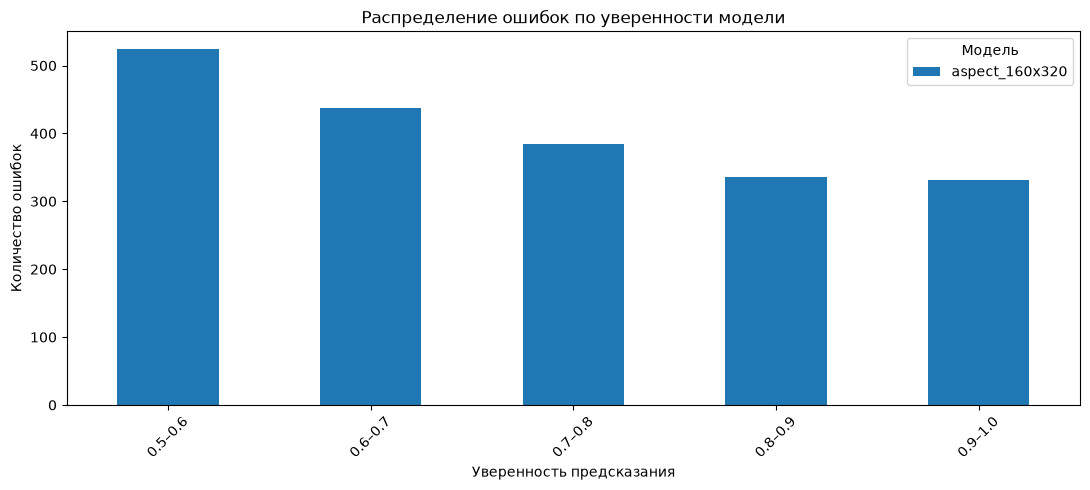

In [33]:
def summarize_binary_predictions(name, probabilities, targets):
    probabilities = np.asarray(probabilities)
    targets = np.asarray(targets).astype(int)
    predictions = (probabilities >= .5).astype(int)
    correct = predictions == targets
    confidence = np.where(predictions == 1, probabilities, 1 - probabilities)
    critical_errors = (~correct) & (confidence > .9)
    errors = int((~correct).sum())
    return {
        'вариант': name,
        'примеров': len(targets),
        'ошибок': errors,
        'ошибок, %': 100 * errors / len(targets),
        'критических ошибок': int(critical_errors.sum()),
        'критических ошибок, %': 100 * critical_errors.mean(),
        'критических среди ошибок, %': 100 * critical_errors.sum() / errors if errors else 0.0,
        'Brier': np.mean((probabilities - targets) ** 2),
        'accuracy': correct.mean(),
    }


def evaluate_run(name, run):
    validation = eval_one_epoch(
        run['model'],
        val_loaders[name],
        collect_predictions=True,
        description=f'Отчёт {name}',
    )
    rows = []
    for logit, probability, target, index in zip(
        validation['logits'],
        validation['probabilities'],
        validation['targets'],
        validation['indices'],
    ):
        source = val_examples.iloc[index // 2]
        prediction = int(probability >= .5)
        confidence = probability if prediction else 1 - probability
        rows.append({
            'index': int(index),
            'file_name': source.file_name,
            'dataset': source.dataset,
            'target': int(target),
            'prediction': prediction,
            'logit': float(logit),
            'p_180': float(probability),
            'confidence': float(confidence),
            'correct': prediction == int(target),
            'brier': float((probability - target) ** 2),
        })

    predictions = pd.DataFrame(rows)
    predictions['high_correct'] = predictions.correct & (predictions.confidence >= .9)
    predictions['high_error'] = ~predictions.correct & (predictions.confidence >= .9)
    report = predictions.groupby('dataset').agg(
        images=('target', 'size'),
        errors=('correct', lambda value: int((~value).sum())),
        high_correct=('high_correct', 'sum'),
        high_error=('high_error', 'sum'),
        brier=('brier', 'mean'),
    ).reset_index()
    report['error_%'] = 100 * report.errors / report.images
    report['high_correct_%'] = 100 * report.high_correct / report.images
    report['high_error_%'] = 100 * report.high_error / report.images
    return predictions, report


evaluations = {}
for name, run in runs.items():
    predictions, report = evaluate_run(name, run)
    evaluations[name] = {
        'dataset': val_datasets[name],
        'predictions': predictions,
        'report': report,
    }
    print(f'\n{name} ({EXPERIMENTS[name]["shape"]})')
    display(report.style.format({
        'error_%': '{:.2f}%',
        'high_correct_%': '{:.2f}%',
        'high_error_%': '{:.2f}%',
        'brier': '{:.5f}',
    }))

# Сравнение с 224×224 появляется только при запуске обоих экспериментов.
if len(evaluations) > 1:
    combined_report = pd.concat([
        evaluation['report'].assign(model=name)
        for name, evaluation in evaluations.items()
    ], ignore_index=True)
    comparison_table = combined_report.pivot(
        index='dataset',
        columns='model',
        values='error_%',
    )
    ax = comparison_table.plot.bar(figsize=(10, 5))
    ax.set(title='Доля ошибок', xlabel='Датасет', ylabel='% validation-примеров')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Модель')
    plt.tight_layout()

    if {'square_224', 'aspect_160x320'} <= set(evaluations):
        square = evaluations['square_224']['report'].set_index('dataset')
        wide = evaluations['aspect_160x320']['report'].set_index('dataset')
        improvement = pd.DataFrame({
            'ошибок меньше': square.errors - wide.errors,
            'ошибок меньше, п.п.': square['error_%'] - wide['error_%'],
            'ошибок меньше, %': 100 * (square['error_%'] - wide['error_%']) / square['error_%'],
            'Brier улучшение, %': 100 * (square.brier - wide.brier) / square.brier,
        }).reset_index()
        display(improvement.style.format({
            'ошибок меньше, п.п.': '{:+.2f} п.п.',
            'ошибок меньше, %': '{:+.2f}%',
            'Brier улучшение, %': '{:+.2f}%',
        }))

# Распределение всех ошибок по интервалам уверенности шириной 0.1.
confidence_bins = np.arange(.5, 1.01, .1)
confidence_labels = [
    f'{left:.1f}–{right:.1f}'
    for left, right in zip(confidence_bins[:-1], confidence_bins[1:])
]
confidence_errors = {}
for name, evaluation in evaluations.items():
    errors = evaluation['predictions'].loc[~evaluation['predictions'].correct, 'confidence']
    confidence_errors[name] = np.histogram(errors, bins=confidence_bins)[0]

ax = pd.DataFrame(confidence_errors, index=confidence_labels).plot.bar(figsize=(11, 5))
ax.set(
    title='Распределение ошибок по уверенности модели',
    xlabel='Уверенность предсказания',
    ylabel='Количество ошибок',
)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Модель')
plt.tight_layout()


##### Ниже посмотрим на топ 10 изображений и изменение в предсказании относительно аугментаций на этой выборке

aspect_160x320: 10 наиболее уверенных ошибок


,index,file_name,dataset,target,prediction,p_180,confidence,brier
0,9121,rustitw_real_0039689.jpg,rustitw_real,1,0,0.000093,1.000000,0.999814
1,9120,rustitw_real_0039689.jpg,rustitw_real,0,1,1.000000,1.000000,1.000000
2,12161,rustitw_real_0055230.jpg,rustitw_real,1,0,0.000010,1.000000,0.999980
3,750,ch4_0066677.png,ch4,0,1,1.000000,1.000000,1.000000
4,9475,rustitw_real_0041155.jpg,rustitw_real,1,0,0.000540,0.999512,0.998921
5,10133,rustitw_real_0044427.jpg,rustitw_real,1,0,0.000267,0.999512,0.999466
6,4517,rustitw_real_0015729.jpg,rustitw_real,1,0,0.001020,0.999023,0.997960
7,6163,rustitw_real_0024271.jpg,rustitw_real,1,0,0.001078,0.999023,0.997846
8,5043,rustitw_real_0018711.jpg,rustitw_real,1,0,0.000989,0.999023,0.998023
9,5042,rustitw_real_0018711.jpg,rustitw_real,0,1,0.999023,0.999023,0.998048


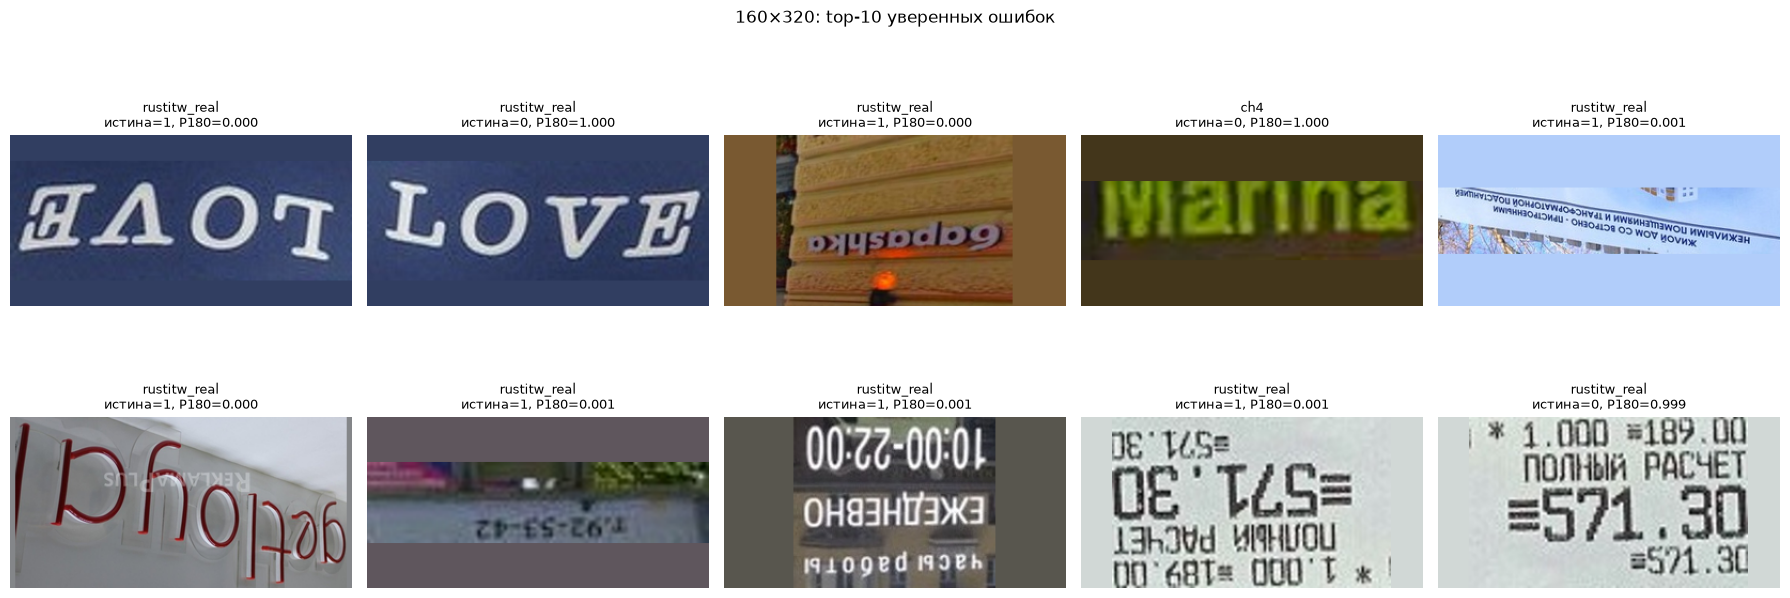

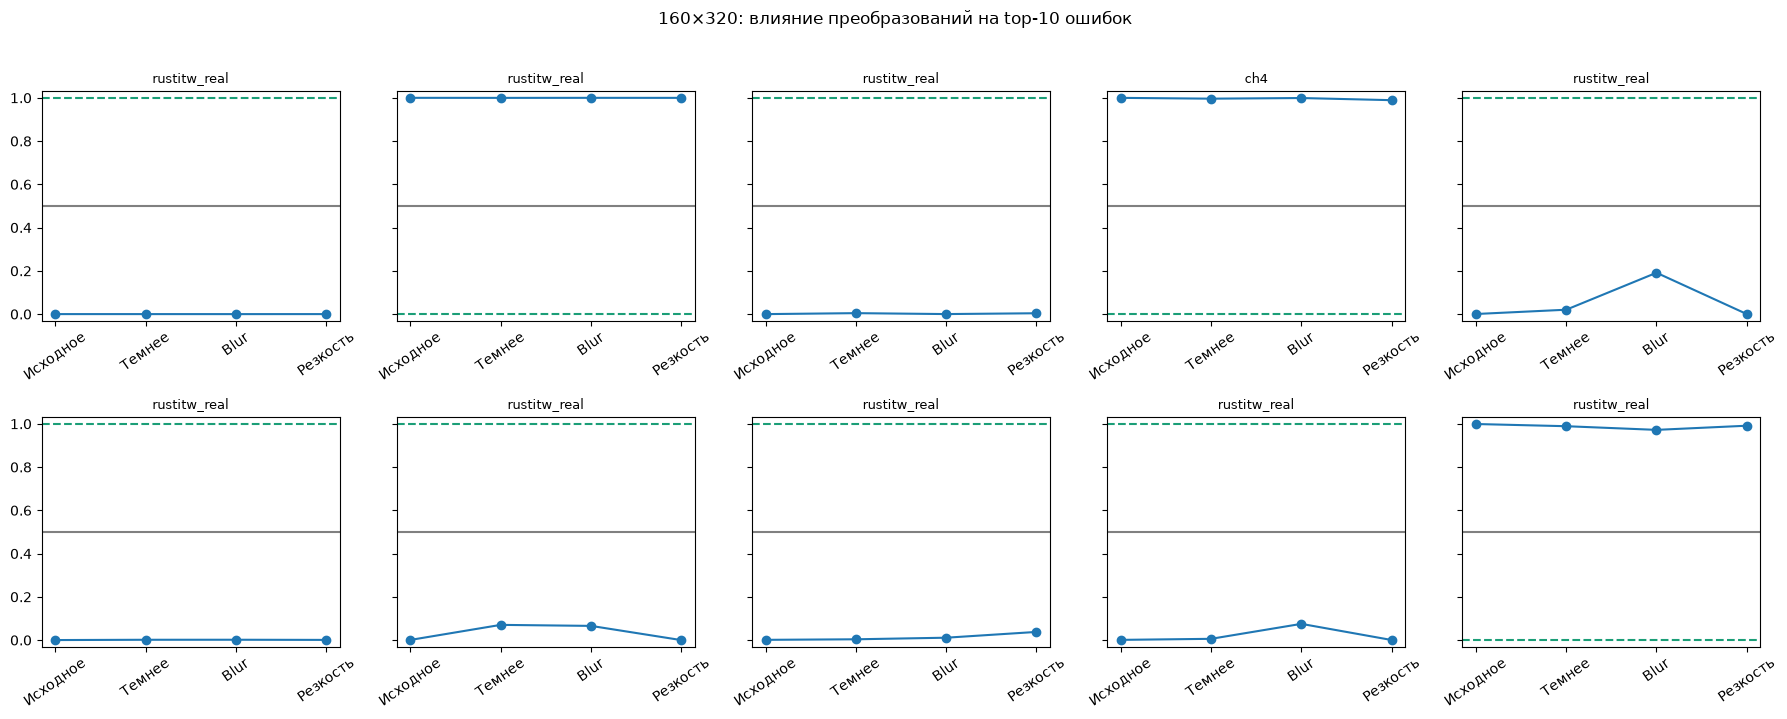

In [34]:
def variant_image(image, variant):
    if variant == 'Исходное':
        return image
    if variant == 'Темнее':
        return ImageEnhance.Brightness(image).enhance(.45)
    if variant == 'Blur':
        return image.filter(ImageFilter.GaussianBlur(radius=2))
    return image.filter(ImageFilter.UnsharpMask(radius=2, percent=180, threshold=3))


name = 'aspect_160x320'
evaluation = evaluations[name]
model = runs[name]['model']
dataset = evaluation['dataset']
hard_errors = (
    evaluation['predictions']
    .loc[~evaluation['predictions'].correct]
    .sort_values('confidence', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(f'{name}: 10 наиболее уверенных ошибок')
error_table = hard_errors[[
    'index', 'file_name', 'dataset', 'target',
    'prediction', 'p_180', 'confidence', 'brier',
]]
display(error_table)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for axis, error in zip(axes.flat, hard_errors.itertuples(index=False)):
    axis.imshow(dataset.load_pil(error.index))
    axis.set_title(
        f'{error.dataset}\nистина={error.target}, P180={error.p_180:.3f}',
        fontsize=9,
    )
    axis.axis('off')
for axis in axes.flat[len(hard_errors):]:
    axis.axis('off')
fig.suptitle('160×320: top-10 уверенных ошибок', y=.98)
plt.tight_layout()

variants = ['Исходное', 'Темнее', 'Blur', 'Резкость']
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
for axis, error in zip(axes.flat, hard_errors.itertuples(index=False)):
    image = dataset.load_pil(error.index)
    probabilities = []
    for variant in variants:
        with torch.no_grad():
            tensor = normalize_image(variant_image(image, variant)).unsqueeze(0).to(DEVICE)
            probability = torch.sigmoid(model(tensor).squeeze()).item()
            probabilities.append(probability)
    axis.plot(variants, probabilities, marker='o')
    axis.axhline(.5, color='gray')
    axis.axhline(error.target, color='#1b9e77', linestyle='--')
    axis.set_ylim(-.03, 1.03)
    axis.set_title(error.dataset, fontsize=9)
    axis.tick_params(axis='x', rotation=35)
for axis in axes.flat[len(hard_errors):]:
    axis.axis('off')
fig.suptitle('160×320: влияние преобразований на top-10 ошибок', y=1.02)
plt.tight_layout()

## 6. Top-10 наиболее уверенных правильных прогнозов 160×320

Эта выборка помогает сопоставить хорошие кропы с ошибками: качество, резкость, фон и степень обрезки текста.

aspect_160x320: top-10 наиболее уверенных правильных прогнозов


,index,file_name,dataset,target,prediction,p_180,confidence,brier
0,3676,rustitw_real_0011485.jpg,rustitw_real,0,0,2.980232e-06,1.0,8.881784e-12
1,3677,rustitw_real_0011485.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
2,3695,rustitw_real_0011782.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
3,3699,rustitw_real_0011795.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
4,3715,rustitw_real_0011888.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
5,3640,rustitw_real_0011420.jpg,rustitw_real,0,0,0.000000e+00,1.0,0.000000e+00
6,3641,rustitw_real_0011420.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
7,3645,rustitw_real_0011422.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
8,3647,rustitw_real_0011423.jpg,rustitw_real,1,1,1.000000e+00,1.0,0.000000e+00
9,3650,rustitw_real_0011425.jpg,rustitw_real,0,0,1.192093e-07,1.0,1.421085e-14


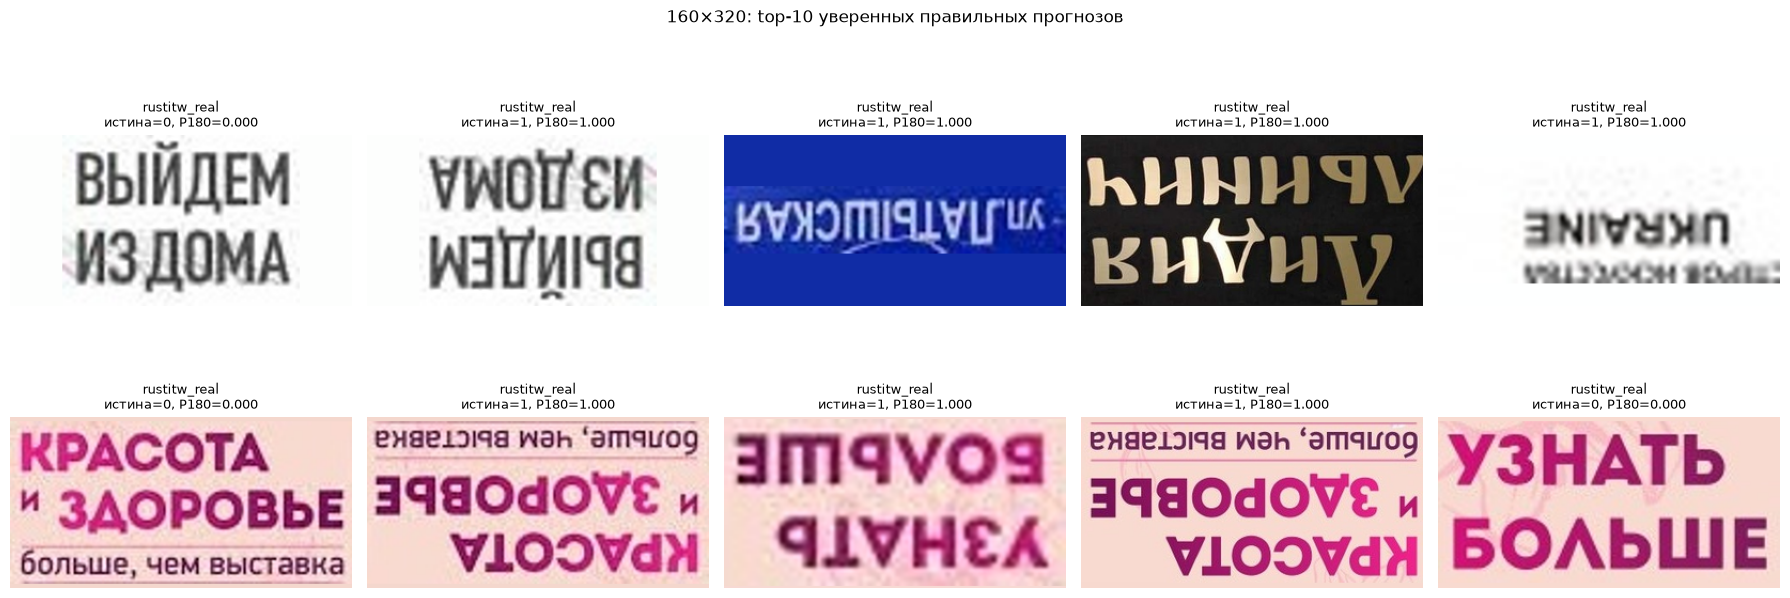

In [35]:
name = 'aspect_160x320'
evaluation = evaluations[name]
dataset = evaluation['dataset']
top_correct = (
    evaluation['predictions']
    .loc[evaluation['predictions'].correct]
    .sort_values('confidence', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(f'{name}: top-10 наиболее уверенных правильных прогнозов')
correct_table = top_correct[[
    'index', 'file_name', 'dataset', 'target',
    'prediction', 'p_180', 'confidence', 'brier',
]]
display(correct_table)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for axis, prediction in zip(axes.flat, top_correct.itertuples(index=False)):
    axis.imshow(dataset.load_pil(prediction.index))
    axis.set_title(
        f'{prediction.dataset}\nистина={prediction.target}, P180={prediction.p_180:.3f}',
        fontsize=9,
    )
    axis.axis('off')
for axis in axes.flat[len(top_correct):]:
    axis.axis('off')
fig.suptitle('160×320: top-10 уверенных правильных прогнозов', y=.98)
plt.tight_layout()

### Сводная устойчивость к аугментациям на validation

Меняется только преобразование, применённое после resize/pad, для обеих ориентаций каждого crop. Критическая ошибка — неверный ответ с уверенностью выше 0.9.

In [36]:
class AugmentedValidationDataset(ValidationRotationDataset):
    def __init__(self, frame, prepare, variant):
        super().__init__(frame, prepare)
        self.variant = variant

    def __getitem__(self, index):
        image = variant_image(self.load_pil(index), self.variant)
        label = index % 2
        return normalize_image(image), torch.tensor(float(label)), index


augmentation_variants = ['Темнее', 'Blur', 'Резкость']
augmentation_datasets = {
    variant: AugmentedValidationDataset(val_examples, prepare_wide, variant)
    for variant in augmentation_variants
}
augmentation_loaders = {
    variant: DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == 'cuda',
    )
    for variant, dataset in augmentation_datasets.items()
}


def evaluate_augmentation(model, loader, variant):
    validation = eval_one_epoch(
        model,
        loader,
        collect_predictions=True,
        description=f'Validation: {variant}',
    )
    return summarize_binary_predictions(
        variant,
        validation['probabilities'],
        validation['targets'],
    )


model = runs['aspect_160x320']['model']
baseline_predictions = evaluations['aspect_160x320']['predictions']
baseline_row = summarize_binary_predictions(
    'Исходное',
    baseline_predictions.p_180,
    baseline_predictions.target,
)
augmentation_report = pd.DataFrame([
    baseline_row,
    *[
        evaluate_augmentation(model, augmentation_loaders[variant], variant)
        for variant in augmentation_variants
    ],
])

baseline = augmentation_report.loc[augmentation_report['вариант'].eq('Исходное')].iloc[0]
augmentation_report['Δ ошибок, п.п.'] = augmentation_report['ошибок, %'] - baseline['ошибок, %']
augmentation_report['Δ критических ошибок, п.п.'] = augmentation_report['критических ошибок, %'] - baseline['критических ошибок, %']
augmentation_report['Δ Brier'] = augmentation_report['Brier'] - baseline['Brier']

display(augmentation_report.style.format({
    'ошибок, %': '{:.2f}%',
    'критических ошибок, %': '{:.2f}%',
    'критических среди ошибок, %': '{:.2f}%',
    'Brier': '{:.5f}',
    'accuracy': '{:.2%}',
    'Δ ошибок, п.п.': '{:+.2f} п.п.',
    'Δ критических ошибок, п.п.': '{:+.2f} п.п.',
    'Δ Brier': '{:+.5f}',
}))


Validation: Темнее:   0%|          | 0/53 [00:00<?, ?it/s]

Validation: Blur:   0%|          | 0/53 [00:00<?, ?it/s]

Validation: Резкость:   0%|          | 0/53 [00:00<?, ?it/s]

,вариант,примеров,ошибок,"ошибок, %",критических ошибок,"критических ошибок, %","критических среди ошибок, %",Brier,accuracy,"Δ ошибок, п.п.","Δ критических ошибок, п.п.",Δ Brier
0,Исходное,13442,2017,15.01%,336,2.50%,16.66%,0.10432,84.99%,+0.00 п.п.,+0.00 п.п.,+0.00000
1,Темнее,13442,2219,16.51%,323,2.40%,14.56%,0.11401,83.49%,+1.50 п.п.,-0.10 п.п.,+0.00969
2,Blur,13442,2339,17.40%,449,3.34%,19.20%,0.12039,82.60%,+2.40 п.п.,+0.84 п.п.,+0.01608
3,Резкость,13442,2288,17.02%,363,2.70%,15.87%,0.11740,82.98%,+2.02 п.п.,+0.20 п.п.,+0.01308


## 7. Исходный RusTitW против EasyOCR-замен

Для EasyOCR-варианта повторно используются предсказания из пункта 6. Дополнительный инференс выполняется только для validation с исходными RusTitW crop. CH4 и IIIT5K в обоих вариантах совпадают. Критическая ошибка — неверный ответ с уверенностью выше 0.9.

In [37]:
# Состав split одинаковый, меняются только принятые EasyOCR crop RusTitW.
original_validation = val_examples.copy()
original_images_dir = ROOT / 'data' / 'dataset' / 'images'
original_validation['path'] = original_validation.file_name.map(
    lambda name: str(original_images_dir / name)
)
mixed_validation = val_examples.copy()

easyocr_share = 100 * mixed_validation.image_variant.eq('easyocr').mean()
print(f'Validation: {len(mixed_validation):,} кропов')
print(f'EasyOCR crop в validation: {easyocr_share:.2f}%')

original_dataset = ValidationRotationDataset(original_validation, prepare_wide)
original_loader = DataLoader(
    original_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)
original_result = eval_one_epoch(
    runs['aspect_160x320']['model'],
    original_loader,
    collect_predictions=True,
    description='Исходный RusTitW',
)

mixed_predictions = evaluations['aspect_160x320']['predictions']
final_comparison = pd.DataFrame([
    summarize_binary_predictions(
        'Исходный RusTitW',
        original_result['probabilities'],
        original_result['targets'],
    ),
    summarize_binary_predictions(
        'EasyOCR-замены RusTitW',
        mixed_predictions.p_180,
        mixed_predictions.target,
    ),
])
display(final_comparison.style.format({
    'ошибок, %': '{:.2f}%',
    'критических ошибок, %': '{:.2f}%',
    'критических среди ошибок, %': '{:.2f}%',
    'Brier': '{:.5f}',
    'accuracy': '{:.2%}',
}))

base = final_comparison.iloc[0]
easy = final_comparison.iloc[1]
change = pd.DataFrame([{
    'Ошибок, изменение': easy['ошибок'] - base['ошибок'],
    'Ошибок, изменение п.п.': easy['ошибок, %'] - base['ошибок, %'],
    'Критических ошибок, изменение': easy['критических ошибок'] - base['критических ошибок'],
    'Критических ошибок, изменение п.п.': easy['критических ошибок, %'] - base['критических ошибок, %'],
    'Brier, изменение': easy['Brier'] - base['Brier'],
}])
display(change.style.format({
    'Ошибок, изменение п.п.': '{:+.2f} п.п.',
    'Критических ошибок, изменение п.п.': '{:+.2f} п.п.',
    'Brier, изменение': '{:+.5f}',
}))


Validation: 6,721 кропов
EasyOCR crop в validation: 34.19%


Исходный RusTitW:   0%|          | 0/53 [00:00<?, ?it/s]

,вариант,примеров,ошибок,"ошибок, %",критических ошибок,"критических ошибок, %","критических среди ошибок, %",Brier,accuracy
0,Исходный RusTitW,13442,2235,16.63%,386,2.87%,17.27%,0.11550,83.37%
1,EasyOCR-замены RusTitW,13442,2017,15.01%,336,2.50%,16.66%,0.10432,84.99%


,"Ошибок, изменение","Ошибок, изменение п.п.","Критических ошибок, изменение","Критических ошибок, изменение п.п.","Brier, изменение"
0,-218,-1.62 п.п.,-50,-0.37 п.п.,-0.01119


## 8. Классификационные метрики на validation

Метрики считаются без аугментаций на validation и при пороге `P(180) ≥ 0.5`. Положительным классом считается поворот 180°.

**Вот тут я бы хотел остановиться и дать расширенный комментарий:**

В тестовом задании основная метрика - ` (1-\text{Brier score}) `. Она оценивает сами вероятности: если модель уверенно ошибается, штраф будет больше. Поэтому в submission.csv я сохраняю вероятности, а не перевожу их в классы с порогом 0,5.

При этом в реальном сценарии предсказание нужно, чтобы повернуть текст перед OCR. Если выбрать неверную ориентацию, OCR может плохо прочитать надпись, а система - пропустить запрещённое содержимое. Поэтому при анализе валидации желательно также смотреть, какие изображения модель классифицирует неправильно и насколько она уверена в этих ошибках.

,accuracy,precision (180°),recall (180°),F1 (180°),specificity (0°),Brier,ошибок,критических ошибок,"критических ошибок, %"
0,84.99%,85.32%,84.54%,84.93%,85.45%,0.104316,2017,336,2.50%


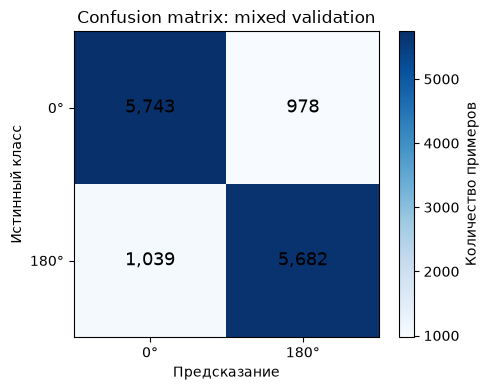

In [38]:
validation_predictions = evaluations['aspect_160x320']['predictions']
probabilities = validation_predictions.p_180.to_numpy()
targets = validation_predictions.target.to_numpy(dtype=int)
predictions = (probabilities >= .5).astype(int)

# Строки — истинный класс, столбцы — предсказание.
tn = int(((targets == 0) & (predictions == 0)).sum())
fp = int(((targets == 0) & (predictions == 1)).sum())
fn = int(((targets == 1) & (predictions == 0)).sum())
tp = int(((targets == 1) & (predictions == 1)).sum())

precision_180 = tp / (tp + fp) if tp + fp else 0.0
recall_180 = tp / (tp + fn) if tp + fn else 0.0
f1_180 = 2 * precision_180 * recall_180 / (precision_180 + recall_180) if precision_180 + recall_180 else 0.0
specificity_0 = tn / (tn + fp) if tn + fp else 0.0
accuracy = (tp + tn) / len(targets)
brier = np.mean((probabilities - targets) ** 2)
confidence = np.where(predictions == 1, probabilities, 1 - probabilities)
critical_errors = int(((predictions != targets) & (confidence > .9)).sum())

metrics = pd.DataFrame([{
    'accuracy': accuracy,
    'precision (180°)': precision_180,
    'recall (180°)': recall_180,
    'F1 (180°)': f1_180,
    'specificity (0°)': specificity_0,
    'Brier': brier,
    'ошибок': int((predictions != targets).sum()),
    'критических ошибок': critical_errors,
    'критических ошибок, %': 100 * critical_errors / len(targets),
}])
display(metrics.style.format({
    'accuracy': '{:.2%}',
    'precision (180°)': '{:.2%}',
    'recall (180°)': '{:.2%}',
    'F1 (180°)': '{:.2%}',
    'specificity (0°)': '{:.2%}',
    'Brier': '{:.6f}',
    'критических ошибок, %': '{:.2f}%',
}))

confusion = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion, cmap='Blues')
for row in range(2):
    for column in range(2):
        ax.text(column, row, f'{confusion[row, column]:,}', ha='center', va='center', fontsize=13)
ax.set_xticks([0, 1], ['0°', '180°'])
ax.set_yticks([0, 1], ['0°', '180°'])
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный класс')
ax.set_title('Confusion matrix: mixed validation')
fig.colorbar(image, ax=ax, label='Количество примеров')
plt.tight_layout()


## 9. Temperature scaling на validation

Температура применяется к logit модели: `P(180) = sigmoid(logit / T)`. Подбор использует validation. При `T > 0` знак logit не меняется, поэтому класс при пороге 0.5 и процент ошибок остаются прежними; изменяются только вероятности и Brier score.

,вариант,temperature,Brier,ошибок,"ошибок, %",средняя P(180),Δ Brier,"Δ ошибок, п.п."
0,Без калибровки,1.00000,0.104316,2017.000000,15.01%,0.4949,+0.000000,+0.00 п.п.
1,Лучшая температура по Brier,1.39637,0.102492,2017.000000,15.01%,0.4949,-0.001824,+0.00 п.п.


Ожидаемо: температура не изменила классы при пороге 0.5, изменились только вероятности и Brier.


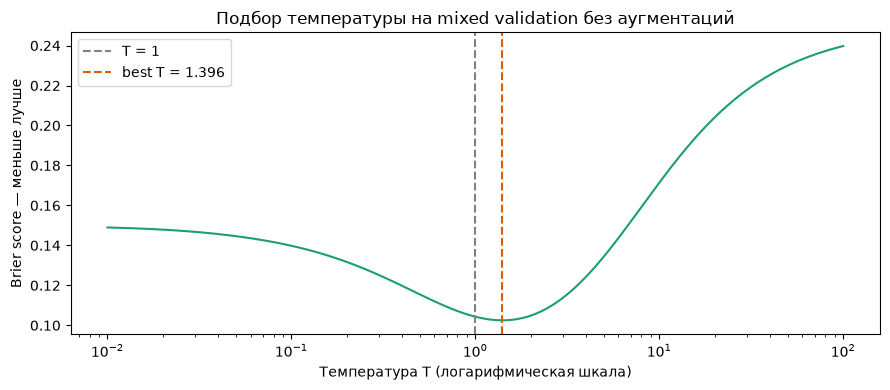

In [39]:
validation_predictions = evaluations['aspect_160x320']['predictions']
logits = validation_predictions.logit.to_numpy()
targets = validation_predictions.target.to_numpy(dtype=int)

# Широкая логарифмическая сетка: T=1 — исходная модель без калибровки.
temperatures = np.unique(np.sort(np.r_[1.0, np.logspace(-2, 2, 801)]))
rows = []
for temperature in temperatures:
    probabilities = 1 / (1 + np.exp(-np.clip(logits / temperature, -80, 80)))
    predictions = probabilities >= .5
    errors = int((predictions != targets.astype(bool)).sum())
    rows.append({
        'temperature': temperature,
        'Brier': np.mean((probabilities - targets) ** 2),
        'ошибок': errors,
        'ошибок, %': 100 * errors / len(targets),
        'средняя P(180)': probabilities.mean(),
    })

temperature_report = pd.DataFrame(rows)
best_temperature = temperature_report.loc[temperature_report.Brier.idxmin()]
baseline_temperature = temperature_report.loc[np.isclose(temperature_report.temperature, 1.0)].iloc[0]

summary = pd.DataFrame([
    {'вариант': 'Без калибровки', **baseline_temperature.to_dict()},
    {'вариант': 'Лучшая температура по Brier', **best_temperature.to_dict()},
])
summary['Δ Brier'] = summary.Brier - baseline_temperature.Brier
summary['Δ ошибок, п.п.'] = summary['ошибок, %'] - baseline_temperature['ошибок, %']
display(summary.style.format({
    'temperature': '{:.5f}',
    'Brier': '{:.6f}',
    'ошибок, %': '{:.2f}%',
    'средняя P(180)': '{:.4f}',
    'Δ Brier': '{:+.6f}',
    'Δ ошибок, п.п.': '{:+.2f} п.п.',
}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(temperature_report.temperature, temperature_report.Brier, color='#1b9e77')
ax.axvline(1.0, color='gray', linestyle='--', label='T = 1')
ax.axvline(best_temperature.temperature, color='#d95f02', linestyle='--', label=f'best T = {best_temperature.temperature:.3f}')
ax.set_xlabel('Температура T (логарифмическая шкала)')
ax.set_ylabel('Brier score — меньше лучше')
ax.set_title('Подбор температуры на mixed validation без аугментаций')
ax.legend()
plt.tight_layout()

if not np.all(temperature_report['ошибок'].eq(baseline_temperature['ошибок'])):
    print('Внимание: число ошибок изменилось; проверьте правило порога.')
else:
    print('Ожидаемо: температура не изменила классы при пороге 0.5, изменились только вероятности и Brier.')


## 10. Submission для модели 160×320

Используется лучший checkpoint эксперимента `aspect_160x320`. Temperature scaling здесь я не применял, так как он не дал большого выигрыша на моей валидации.

Для получения submission достаточно запустить следующие две ячейки: первая автономно загружает локальный checkpoint и определяет preprocessing, вторая выполняет инференс на тестовой выборке. Train-датасет и выполнение предыдущих ячеек для этого не нужны. Если все предыдущие были запущены, то следующую можно не запускать.

In [1]:
# Автономная подготовка модели для submission: train-ячейки выше запускать не нужно.
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_small

ROOT = Path.cwd()
CHECKPOINT_PATH = ROOT / 'mobilenet_rotation_easy_aspect_160x320_best.pt'
BATCH_SIZE = 256
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint не найден: {CHECKPOINT_PATH}. '
        'Положите файл рядом с main.ipynb.'
    )


def inference_normalize(image):
    return transforms.functional.normalize(
        transforms.functional.to_tensor(image),
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )


def inference_prepare_wide(image):
    target_height, target_width = 160, 320
    image = image.convert('RGB')
    width, height = image.size
    scale = min(target_width / width, target_height / height)
    new_width = max(1, round(width * scale))
    new_height = max(1, round(height * scale))

    interpolation = Image.Resampling.LANCZOS if scale < 1 else Image.Resampling.BICUBIC
    image = image.resize((new_width, new_height), interpolation)

    pixels = np.asarray(image)
    border = np.concatenate([pixels[0], pixels[-1], pixels[:, 0], pixels[:, -1]])
    fill = tuple(int(value) for value in np.median(border, axis=0))

    canvas = Image.new('RGB', (target_width, target_height), fill)
    offset = ((target_width - new_width) // 2, (target_height - new_height) // 2)
    canvas.paste(image, offset)
    return canvas


def build_inference_model():
    # В checkpoint хранится полный state_dict, поэтому ImageNet-веса скачивать не нужно.
    model = mobilenet_v3_small(weights=None)
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    return model


checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
model_160x320 = build_inference_model().to(DEVICE)
model_160x320.load_state_dict(checkpoint['model_state_dict'])
model_160x320.eval()
print(f'Checkpoint загружен: {CHECKPOINT_PATH.name}; устройство: {DEVICE}')


Checkpoint загружен: mobilenet_rotation_easy_aspect_160x320_best.pt; устройство: cuda


In [2]:
TEST_IMAGES_DIR = ROOT / 'test' / 'images'
SUBMISSION_PATH = ROOT / 'submission.csv'

test_image_paths = sorted(
    path for path in TEST_IMAGES_DIR.iterdir()
    if path.suffix.lower() in {'.png', '.jpg', '.jpeg'}
)
if not test_image_paths:
    raise FileNotFoundError(f'В папке {TEST_IMAGES_DIR} нет test-изображений.')

test_paths = {path.stem: path for path in test_image_paths}
if len(test_paths) != len(test_image_paths):
    raise ValueError('В test-папке найдены файлы с одинаковым image_id.')
test_image_ids = sorted(test_paths)


class TestRotationDataset(Dataset):
    def __init__(self, image_ids, paths):
        self.image_ids = list(image_ids)
        self.paths = paths

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        image_id = self.image_ids[index]
        with Image.open(self.paths[image_id]) as opened:
            image = opened.convert('RGB')
        return inference_normalize(inference_prepare_wide(image)), image_id


test_dataset = TestRotationDataset(test_image_ids, test_paths)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)

predicted_ids, predicted_probabilities = [], []
with torch.inference_mode():
    for images, image_ids in tqdm(test_loader, desc='Test inference 160×320'):
        logits = model_160x320(images.to(DEVICE, non_blocking=True)).squeeze(1)
        probabilities = torch.sigmoid(logits).cpu().numpy()
        predicted_ids.extend(image_ids)
        predicted_probabilities.extend(probabilities.tolist())

submission = pd.DataFrame({
    'image_id': predicted_ids,
    'p_180': predicted_probabilities,
})

submission.to_csv(SUBMISSION_PATH, index=False)
print(f'Submission сохранён: {SUBMISSION_PATH}')
display(submission.head())

Test inference 160×320:   0%|          | 0/79 [00:00<?, ?it/s]

Submission сохранён: /home/mycra/avito-bootcamp/submission.csv


,image_id,p_180
0,test_00000,0.209447
1,test_00001,0.999822
2,test_00002,1.000000
3,test_00003,0.016904
4,test_00004,0.999739


## Финальные мысли 
### Гипотезы о том, что можно было бы попробовать/сделать по-другому

Я по смыслу также разобью на блоки:

### Данные

- Я думаю, можно было бы попробовать взять другие датасеты и получить кропы с помощью easyOCR, так как он довольно хорошо распознает bbox текста и его кропы похожи на тестовую выборку. Ещё можно было использовать синтетические изображения из rustitw, но мне они не очень понравились, так как имели сильные нереалистичные изгибы.

- Я не применял аугментации, хотя можно было бы попробовать, так как текст встречается разным (опять же, некоторый размытый, слишком светлый и тд).

- Аналогично аугментации, у меня была следующая мысль: текст стараются так или иначе сделать контрастным с фоном, а также шрифт часто имеет один и тот же цвет. Это можно было бы совместить с каким-нибудь классическим фильтром, чтобы лучше выделять текст от фона, но так как в rustitw встречаются сложные фоны, такой фильтр мог бы наоборот немного навредить обучению. Тем не менее я считаю это хорошим замечанием, несмотря на то, что я это не попробовал.

### Обучение

- тут все по классике: разные модели, разные гиперпараметры и тд. Единственное, что я бы хотел отметить, я не вижу смысла для использования тяжелой модели, но просто другую архитектуру попробовать можно было.

- как я упоминал в начале ноутбука, можно было бы попробовать взвешенную связку BCE лосса с Brier score. Возможно это улучшило бы итоговую метрику. Также можно было бы добавить penalty за то, что сумма P(180|0) + P(180|180) != 1.


### Анализ ошибок

- вот тут можно разгуляться. Анализ ошибок - хорошее место чтоб найти, в чем проблемы модели. Когда я первый раз обучил модель, я сразу заметил, что в топ-10 на валидационной выборке очень огромные кропы и текста в несколько строк. Я разметил эти топ 10 изображений (опять же, это валидационная выборка, не тестовая) в более плотные кропы и на 8 из 10 изображений классы поменялись. То есть ошибки были из-за некачественного bbox'а. Именно поэтому я в дальнейшем использовал easyOCR для обрезки rustitw.


#### На этом всё. Огромное спасибо за прочтение ноутбука и проверку работы!